<a href="https://colab.research.google.com/github/emirmaciastec/MEM_M-todos_estadisticos/blob/main/lab2_4_nhanes_univariate_practice_Equipo9_HW_2_AraiSantiago.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IN4028 Métodos Estadísticos y Visualización

#### Doctor Carlos A. Díaz Tufinio
#### Maestra María Josefina Macías Rodríguez
#### Ingeniero Ramón Godina

##### María José Ayala Villanueva – A01797363
##### Emir Macías Sifuentes – A01797255
##### Juan Luis Nolazco Cervantes– A01797407
##### Soledad Arai Santiago Hernández - A01797345
##### Luciano Andrés Pilati - A01634098

# Homework Assignment 2 - Part 3

## Lab2 4 Nhanes_univariate_practice

# Practice notebook for univariate analysis using NHANES data

This notebook will give you the opportunity to perform some univariate analyses on your own using the NHANES.  These analyses are similar to what was done in the week 2 NHANES case study notebook.

You can enter your code into the cells that say "enter your code here", and you can type responses to the questions into the cells that say "Type Markdown and Latex".

Note that most of the code that you will need to write below is very similar to code that appears in the case study notebook.  You will need to edit code from that notebook in small ways to adapt it to the prompts below.

To get started, we will use the same module imports and read the data in the same way as we did in the case study:

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np

da = pd.read_csv("nhanes_2015_2016-1.csv")

In [ ]:
da.head ()

,SEQN,ALQ101,ALQ110,ALQ130,SMQ020,RIAGENDR,RIDAGEYR,RIDRETH1,DMDCITZN,DMDEDUC2,...,MaritalStatus,Gender,AgeGrp,AgeGrp2,HeightGrp,BP_diff,DMDEDUC2x,EDU,HouseGrp,Edulvl
0,83732,1.0,NaN,1.0,1,1,62,3,1.0,5.0,...,Married,Male,NaN,"(60, 70]","(180, 190]",4.0,College,College,"(1.0, 2.0]",College
1,83733,1.0,NaN,6.0,1,1,53,3,2.0,3.0,...,Divorced,Male,NaN,"(50, 60]","(170, 180]",6.0,HS/GED,HS/GED,NaN,HS/GED
2,83734,1.0,NaN,NaN,1,1,78,3,1.0,3.0,...,Married,Male,NaN,"(70, 80]","(170, 180]",6.0,HS/GED,HS/GED,"(1.0, 2.0]",HS/GED
3,83735,2.0,1.0,1.0,2,2,56,3,1.0,5.0,...,Living with partner,Female,NaN,"(50, 60]","(160, 170]",-2.0,College,College,NaN,College
4,83736,2.0,1.0,1.0,2,2,42,4,1.0,4.0,...,Divorced,Female,NaN,"(40, 50]","(160, 170]",-14.0,Some college/AA,Some college/AA,"(4.0, 5.0]",Some college/AA


## Question 1

Relabel the marital status variable [DMDMARTL](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDMARTL) to have brief but informative character labels.  Then construct a frequency table of these values for all people, then for women only, and for men only.  Then construct these three frequency tables using only people whose age is between 30 and 40.

In [ ]:
da.DMDMARTL.value_counts()

1.0     2780
5.0     1004
3.0      579
6.0      527
2.0      396
4.0      186
77.0       2
Name: DMDMARTL, dtype: int64

In [ ]:
da["MaritalStatus"] = da.DMDMARTL.replace({1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separeted", 5: "Never married", 6: "Living with partner",
                                       77: "Refused", 99: "Don't Know"}) #Relabel values in a new column
da.MaritalStatus.value_counts()

Married                2780
Never married          1004
Divorced                579
Living with partner     527
Widowed                 396
Separeted               186
Refused                   2
Name: MaritalStatus, dtype: int64

In [ ]:
da["Gender"] = da.RIAGENDR.replace({1: "Male", 2: "Female"}) #relabel values in new column

In [ ]:
da.groupby("Gender")["MaritalStatus"].value_counts() #Group by Gender and Marital Status

Gender  MaritalStatus      
Female  Married                1303
        Never married           520
        Divorced                350
        Widowed                 296
        Living with partner     262
        Separeted               118
        Refused                   1
Male    Married                1477
        Never married           484
        Living with partner     265
        Divorced                229
        Widowed                 100
        Separeted                68
        Refused                   1
Name: MaritalStatus, dtype: int64

In [ ]:
da["AgeGrp"] = pd.cut(da.RIDAGEYR, [30, 40,]) #Group only by 30,40

In [ ]:
da.groupby(["AgeGrp", "Gender"])["MaritalStatus"].value_counts()

AgeGrp    Gender  MaritalStatus      
(30, 40]  Female  Married                258
                  Never married           97
                  Living with partner     57
                  Divorced                43
                  Separeted               17
                  Widowed                  2
          Male    Married                258
                  Never married           89
                  Living with partner     72
                  Divorced                24
                  Separeted               12
                  Widowed                  2
                  Refused                  1
Name: MaritalStatus, dtype: int64

__Q1a.__ Briefly comment on some of the differences that you observe between the distribution of marital status between women and men, for people of all ages.

According to the data, men are married or living with their partners more than women, otherwise women are more widower than mens

__Q1b.__ Briefly comment on the differences that you observe between the distribution of marital status states for women between the overall population, and for women between the ages of 30 and 40.

__Q1c.__ Repeat part b for the men.

## Question 2

Restricting to the female population, stratify the subjects into age bands no wider than ten years, and construct the distribution of marital status within each age band.  Within each age band, present the distribution in terms of proportions that must sum to 1.

In [ ]:
da["AgeGrp2"] = pd.cut(da.RIDAGEYR, [10,20,30,40,50,60,70,80,90]) #Group by 10 years

In [ ]:
dx = da.loc [~da.Gender.isin(["Male"]), :] #Remove Male Gender
dx = dx.groupby(["AgeGrp2","Gender"])["MaritalStatus"] #Group by Age group, Gender and Marital Status
dx = dx.value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'
dx = dx.apply(lambda x: x/x.sum(), axis=1) # Normalize within each stratum to get proportions
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places


MaritalStatus    Divorced  Living with partner  Married  Never married  Refused  Separeted  Widowed
AgeGrp2  Gender                                                                                    
(10, 20] Female       NaN                0.205    0.026          0.769      NaN        NaN      NaN
(20, 30] Female     0.021                0.206    0.305          0.446      NaN      0.021      NaN
(30, 40] Female     0.091                0.120    0.544          0.205      NaN      0.036    0.004
(40, 50] Female     0.137                0.074    0.574          0.125      NaN      0.066    0.024
(50, 60] Female     0.177                0.068    0.547          0.089    0.002      0.057    0.060
(60, 70] Female     0.193                0.043    0.481          0.086      NaN      0.050    0.147
(70, 80] Female     0.144                0.007    0.317          0.051      NaN      0.020    0.461


__Q2a.__ Comment on the trends that you see in this series of marginal distributions.

__Q2b.__ Repeat the construction for males.

In [ ]:
dx = da.loc [~da.Gender.isin(["Female"]), :] #Remove Male Gender
dx = dx.groupby(["AgeGrp2","Gender"])["MaritalStatus"] #Group by Age group, Gender and Marital Status
dx = dx.value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'
dx = dx.apply(lambda x: x/x.sum(), axis=1) # Normalize within each stratum to get proportions
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places

MaritalStatus    Divorced  Living with partner  Married  Never married  Refused  Separeted  Widowed
AgeGrp2  Gender                                                                                    
(10, 20] Male         NaN                0.075    0.025          0.900      NaN        NaN      NaN
(20, 30] Male       0.005                0.213    0.238          0.523      NaN      0.016    0.005
(30, 40] Male       0.052                0.157    0.563          0.194    0.002      0.026    0.004
(40, 50] Male       0.085                0.082    0.703          0.097      NaN      0.027    0.005
(50, 60] Male       0.126                0.075    0.652          0.104      NaN      0.022    0.022
(60, 70] Male       0.126                0.050    0.666          0.087      NaN      0.032    0.039
(70, 80] Male       0.142                0.022    0.612          0.022      NaN      0.035    0.167


__Q2c.__ Comment on any notable differences that you see when comparing these results for females and for males.

## Question 3

Construct a histogram of the distribution of heights using the BMXHT variable in the NHANES sample.

Text(0.5, 9.444444444444438, 'Height')

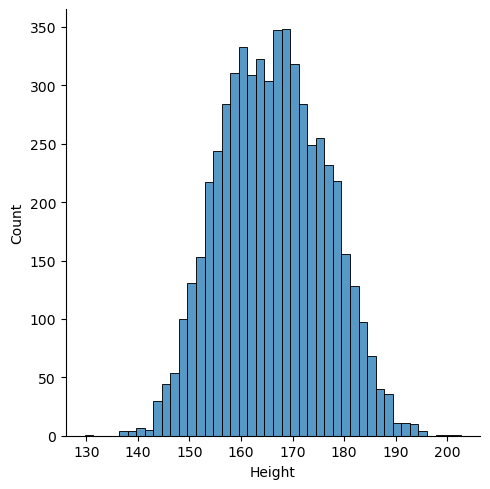

In [ ]:
sns.displot(da.BMXHT.dropna())
plt.xlabel("Height") #Change X label

__Q3a.__ Use the `bins` argument to [distplot](https://seaborn.pydata.org/generated/seaborn.distplot.html) to produce histograms with different numbers of bins.  Assess whether the default value for this argument gives a meaningful result, and comment on what happens as the number of bins grows excessively large or excessively small.

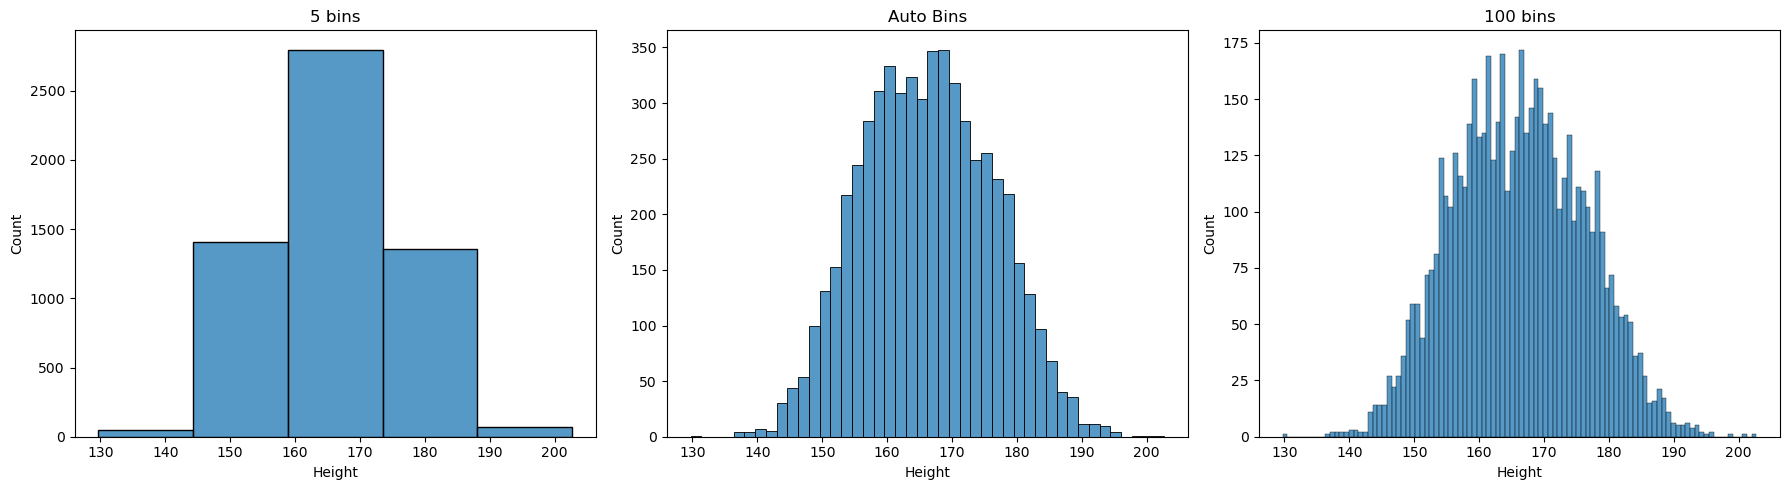

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) #Show 3 tables

# 5 bins
sns.histplot(altura, bins=5, ax=axes[0]) #Number of Bins
axes[0].set_title('5 bins') #Set Title

# Auto Bins
sns.histplot(altura, ax=axes[1]) #Number of Bins
axes[1].set_title('Auto Bins') #Set Title

# 100 Bins
sns.histplot(altura, bins=100, ax=axes[2]) #Number of Bins
axes[2].set_title('100 bins') #Set Title

for ax in axes:
    ax.set_xlabel("Height") #Change X label

plt.tight_layout()
plt.show()

Answer

__Q3b.__ Make separate histograms for the heights of women and men, then make a side-by-side boxplot showing the heights of women and men.

In [ ]:
Women = da[da['RIAGENDR'] == 2]['BMXHT'].dropna() # Filter Data by Women
Men = da[da['RIAGENDR'] == 1]['BMXHT'].dropna() # Filter Data by Men

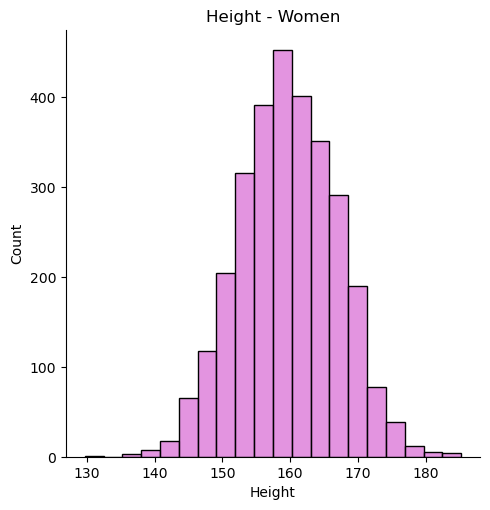

In [ ]:
sns.displot(Women, bins=20, color='orchid')
plt.title("Height - Women") #Set Title
plt.xlabel("Height") #Change X label
plt.show()

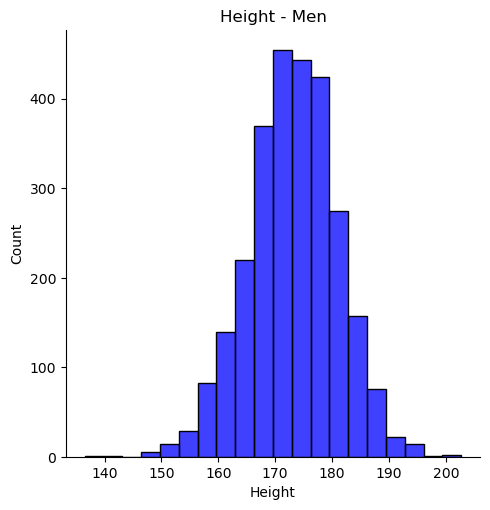

In [ ]:
sns.displot(Men, bins=20, color='blue')
plt.title("Height - Men") #Set Title
plt.xlabel("Height") #Change X label
plt.show()

Text(0, 0.5, 'Height')

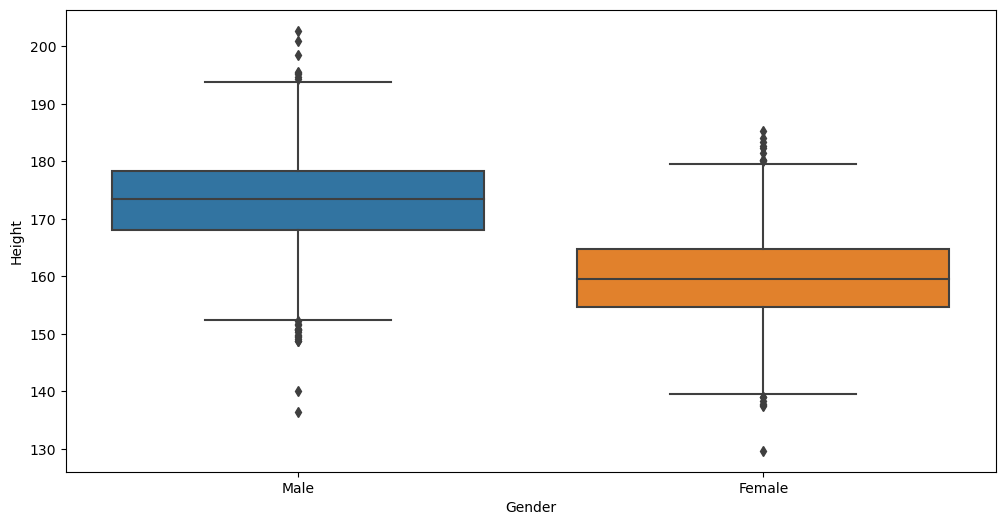

In [ ]:
plt.figure(figsize=(12, 6)) #Set Figure Size
sns.boxplot(x="Gender", y="BMXHT", data=da)
plt.ylabel ("Height") #Change Y label

<Axes: xlabel='Gender', ylabel='BMXHT'>

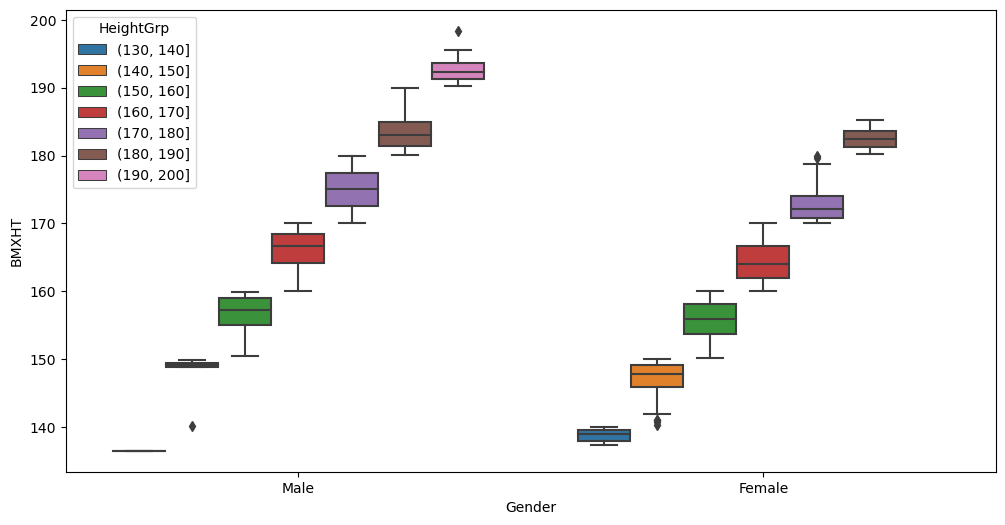

In [ ]:
da["HeightGrp"] = pd.cut(da.BMXHT, [130, 140, 150, 160, 170, 180, 190, 200]) #Group by height
plt.figure(figsize=(12, 6)) #Set figure size
sns.boxplot(x="Gender", y="BMXHT", hue="HeightGrp", data=da)

__Q3c.__ Comment on what features, if any are not represented clearly in the boxplots, and what features, if any, are easier to see in the boxplots than in the histograms.

## Question 4

Make a boxplot showing the distribution of within-subject differences between the first and second systolic blood pressure measurents ([BPXSY1](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY1) and [BPXSY2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY2)).

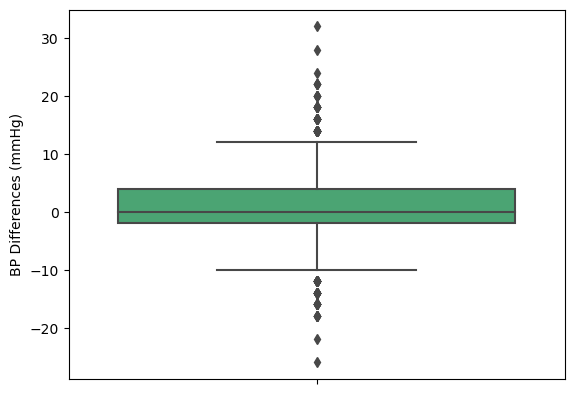

In [ ]:
da['BP_diff'] = da['BPXSY1'] - da['BPXSY2']
bp_diff = da['BP_diff'].dropna() # Delete null values
sns.boxplot(y=bp_diff, color='mediumseagreen')
plt.ylabel('BP Differences (mmHg)') #Change Y label
plt.show()

__Q4a.__ What proportion of the subjects have a lower SBP on the second reading compared to the first?

In [ ]:
# insert your code here

__Q4b.__ Make side-by-side boxplots of the two systolic blood pressure variables.

Text(0, 0.5, 'Blood pressure in mm/Hg')

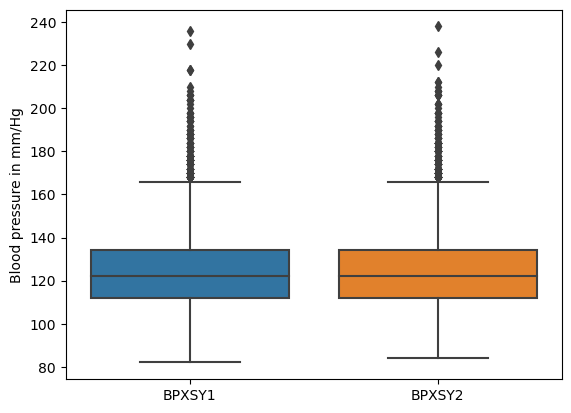

In [ ]:
sns.boxplot(data=da.loc[:, ["BPXSY1", "BPXSY2"]])
plt.ylabel("Blood pressure in mm/Hg") #change Y label

__Q4c.__ Comment on the variation within either the first or second systolic blood pressure measurements, and the variation in the within-subject differences between the first and second systolic blood pressure measurements.

## Question 5

Construct a frequency table of household sizes for people within each educational attainment category (the relevant variable is [DMDEDUC2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDEDUC2)).  Convert the frequencies to proportions.

In [ ]:
da.DMDEDUC2.value_counts()

4.0    1621
5.0    1366
3.0    1186
1.0     655
2.0     643
9.0       3
Name: DMDEDUC2, dtype: int64

In [ ]:
da["Edulvl"] = da.DMDEDUC2.replace({1: "<9", 2: "9-11", 3: "HS/GED", 4: "Some college/AA", 5: "College",
                                       7: "Refused", 9: "Don't know"}) #Replace values
da.Edulvl.value_counts()

Some college/AA    1621
College            1366
HS/GED             1186
<9                  655
9-11                643
Don't know            3
Name: Edulvl, dtype: int64

In [ ]:
da.groupby(["DMDHHSIZ"])["Edulvl"].value_counts()

DMDHHSIZ  Edulvl         
1         Some college/AA    245
          College            195
          HS/GED             181
          9-11                75
          <9                  72
2         College            475
          Some college/AA    436
          HS/GED             321
          <9                 147
          9-11               143
          Don't know           2
3         Some college/AA    313
          College            265
          HS/GED             203
          9-11               105
          <9                  96
4         Some college/AA    274
          College            226
          HS/GED             192
          9-11                98
          <9                  87
5         Some college/AA    198
          College            130
          HS/GED             130
          <9                  97
          9-11                94
          Don't know           1
6         Some college/AA     82
          HS/GED              78
          9-11   

In [ ]:
dx = da.groupby(["DMDHHSIZ"])["Edulvl"].value_counts()
dx = dx.unstack() # Restructure the results from 'long' to 'wide'
dx = dx.apply(lambda x: x/x.sum()) # Normalize within each stratum to get proportions
print(dx.to_string(float_format="%.3f"))  # Limit display to 3 decimal places

Edulvl    9-11    <9  College  Don't know  HS/GED  Some college/AA
DMDHHSIZ                                                          
1        0.117 0.110    0.143         NaN   0.153            0.151
2        0.222 0.224    0.348       0.667   0.271            0.269
3        0.163 0.147    0.194         NaN   0.171            0.193
4        0.152 0.133    0.165         NaN   0.162            0.169
5        0.146 0.148    0.095       0.333   0.110            0.122
6        0.114 0.108    0.029         NaN   0.066            0.051
7        0.086 0.130    0.026         NaN   0.068            0.045


__Q5a.__ Comment on any major differences among the distributions.

__Q5b.__ Restrict the sample to people between 30 and 40 years of age.  Then calculate the median household size for women and men within each level of educational attainment.

In [ ]:
x = da[(da['RIDAGEYR'] >= 30) & (da['RIDAGEYR'] <= 40)] # Filter Years
x = x[['Gender', 'Edulvl', 'DMDHHSIZ']].dropna() # Extract all non-missing values
median = (x.groupby(['Gender', 'Edulvl'])['DMDHHSIZ'].median().unstack())
print (median)

Edulvl  9-11   <9  College  HS/GED  Some college/AA
Gender                                             
Female   5.0  5.0      3.0     5.0              4.0
Male     4.5  5.0      3.0     4.0              4.0


## Question 6

The participants can be clustered into "maked variance units" (MVU) based on every combination of the variables [SDMVSTRA](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#SDMVSTRA) and [SDMVPSU](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#SDMVPSU).  Calculate the mean age ([RIDAGEYR](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#RIDAGEYR)), height ([BMXHT](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BMX_I.htm#BMXHT)), and BMI ([BMXBMI](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BMX_I.htm#BMXBMI)) for each gender ([RIAGENDR](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#RIAGENDR)), within each MVU, and report the ratio between the largest and smallest mean (e.g. for height) across the MVUs.

In [ ]:
# Filtrar columnas relevantes y eliminar nulos
subset = da[['SDMVSTRA', 'SDMVPSU', 'RIAGENDR', 'RIDAGEYR', 'BMXHT', 'BMXBMI']].dropna()

# Agrupar por MVU y género
mvu_means = (
    subset
    .groupby(['SDMVSTRA', 'SDMVPSU', 'RIAGENDR'])
    .agg({
        'RIDAGEYR': 'mean',
        'BMXHT': 'mean',
        'BMXBMI': 'mean'
    })
    .reset_index()
)

# Calcular ratios entre máximos y mínimos por variable
ratio_age = mvu_means['RIDAGEYR'].max() / mvu_means['RIDAGEYR'].min()
ratio_height = mvu_means['BMXHT'].max() / mvu_means['BMXHT'].min()
ratio_bmi = mvu_means['BMXBMI'].max() / mvu_means['BMXBMI'].min()

# Mostrar resultados
print("Ratio entre la media más alta y más baja por MVU:")
print(f"Edad: {ratio_age:.2f}")
print(f"Altura: {ratio_height:.2f}")
print(f"BMI: {ratio_bmi:.2f}")

Ratio entre la media más alta y más baja por MVU:
Edad: 1.32
Altura: 1.14
BMI: 1.28


__Q6a.__ Comment on the extent to which mean age, height, and BMI vary among the MVUs.

__Q6b.__ Calculate the inter-quartile range (IQR) for age, height, and BMI for each gender and each MVU.  Report the ratio between the largest and smalles IQR across the MVUs.

In [ ]:
# Filtrar columnas relevantes y eliminar nulos
subset = da[['SDMVSTRA', 'SDMVPSU', 'RIAGENDR', 'RIDAGEYR', 'BMXHT', 'BMXBMI']].dropna()

# Agrupar por MVU y género, y calcular IQR para cada variable
iqr_table = (
    subset
    .groupby(['SDMVSTRA', 'SDMVPSU', 'RIAGENDR'])
    .agg({
        'RIDAGEYR': lambda x: x.quantile(0.75) - x.quantile(0.25),
        'BMXHT': lambda x: x.quantile(0.75) - x.quantile(0.25),
        'BMXBMI': lambda x: x.quantile(0.75) - x.quantile(0.25)
    })
    .reset_index()
)

# Calcular ratios entre el IQR máximo y mínimo por variable
ratio_age_iqr = iqr_table['RIDAGEYR'].max() / iqr_table['RIDAGEYR'].min()
ratio_height_iqr = iqr_table['BMXHT'].max() / iqr_table['BMXHT'].min()
ratio_bmi_iqr = iqr_table['BMXBMI'].max() / iqr_table['BMXBMI'].min()

# Mostrar resultados
print("Ratio entre el IQR más grande y más pequeño por MVU y género:")
print(f"Edad: {ratio_age_iqr:.2f}")
print(f"Altura: {ratio_height_iqr:.2f}")
print(f"BMI: {ratio_bmi_iqr:.2f}")

Ratio entre el IQR más grande y más pequeño por MVU y género:
Edad: 1.80
Altura: 1.62
BMI: 2.87


__Q6c.__ Comment on the extent to which the IQR for age, height, and BMI vary among the MVUs.